IRIS FLOWER CLASSIFICATION - KNN

Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

Class Distribution:
setosa: 50 samples
versicolor: 50 samples
virginica: 50 samples

------------------------------------------------------------
TRAIN-TEST SPLIT
------------------------------------------------------------
Training samples: 120
Testing samples : 30

------------------------------------------------------------
MODEL RESULTS
------------------------------------------------------------
Algorithm          : K-Nearest Neighbors (KNN)
Implementation     : From Scratch using NumPy
Distance Metric    : Euclidean Distance
K                  : 5
Training Samples   : 120
Testing Samples    : 30
Accuracy           : 0.9667
Accuracy (%)       : 96.67%

Confusion Matrix:
[[ 7  0  0]
 [ 0 11  0]
 [ 0  1 11]]

Rows    = Actual Class
Columns = Predicted Class

-------------------------------

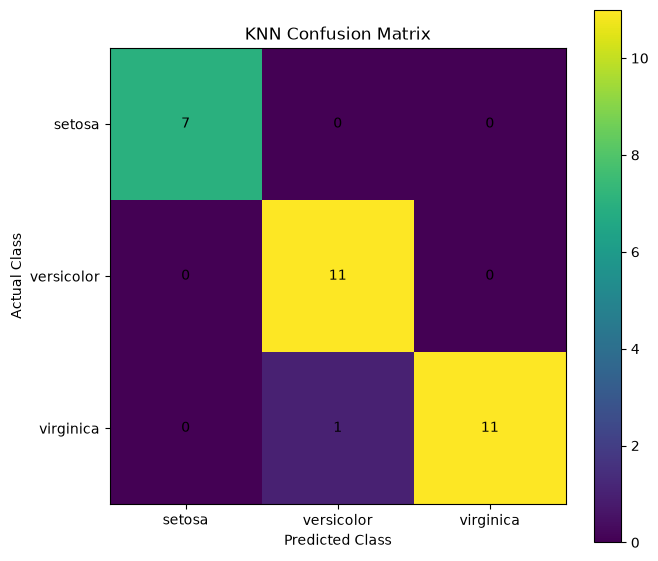


FINAL EXPERIMENT SUMMARY
Dataset            : Iris
Algorithm          : K-Nearest Neighbors
Implementation     : From Scratch
Distance           : Euclidean
K                  : 5
Features           : 4
Training Samples   : 120
Testing Samples    : 30
Accuracy           : 96.67%
Macro Precision    : 0.9722
Macro Recall       : 0.9722
Macro F1           : 0.9710

Experiment completed successfully.


In [1]:
# ============================================================
# ASSIGNMENT 3: IRIS FLOWER CLASSIFICATION
# K-NEAREST NEIGHBORS (KNN) FROM SCRATCH
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris


# ============================================================
# 1. LOAD DATASET
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("=" * 60)
print("IRIS FLOWER CLASSIFICATION - KNN")
print("=" * 60)

print("\nDataset Shape:", X.shape)
print("Features:", feature_names)
print("Classes:", target_names)

print("\nClass Distribution:")
for class_id, class_name in enumerate(target_names):
    print(f"{class_name}: {np.sum(y == class_id)} samples")


# ============================================================
# 2. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("\n" + "-" * 60)
print("TRAIN-TEST SPLIT")
print("-" * 60)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 3. STANDARDIZATION FROM SCRATCH
# ============================================================

# KNN is distance-based, so feature scaling is important.

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Prevent division by zero
std[std == 0] = 1

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std


# ============================================================
# 4. KNN IMPLEMENTATION FROM SCRATCH
# ============================================================

class KNNFromScratch:

    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict_single(self, x):

        # Calculate distance from x to every training point
        distances = []

        for i in range(len(self.X_train)):

            distance = self.euclidean_distance(
                x,
                self.X_train[i]
            )

            distances.append((distance, self.y_train[i]))

        # Sort by distance
        distances.sort(key=lambda pair: pair[0])

        # Select k nearest neighbors
        nearest_neighbors = distances[:self.k]

        # Extract their classes
        neighbor_labels = [
            label for distance, label in nearest_neighbors
        ]

        # Majority voting
        labels, counts = np.unique(
            neighbor_labels,
            return_counts=True
        )

        predicted_class = labels[np.argmax(counts)]

        return predicted_class

    def predict(self, X):

        predictions = []

        for x in X:
            predictions.append(self.predict_single(x))

        return np.array(predictions)


# ============================================================
# 5. TRAIN KNN MODEL
# ============================================================

k = 5

model = KNNFromScratch(k=k)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


# ============================================================
# 6. EVALUATION METRICS FROM SCRATCH
# ============================================================

accuracy = np.mean(y_pred == y_test)

print("\n" + "-" * 60)
print("MODEL RESULTS")
print("-" * 60)

print("Algorithm          : K-Nearest Neighbors (KNN)")
print("Implementation     : From Scratch using NumPy")
print("Distance Metric    : Euclidean Distance")
print("K                  :", k)
print("Training Samples   :", len(X_train))
print("Testing Samples    :", len(X_test))
print(f"Accuracy           : {accuracy:.4f}")
print(f"Accuracy (%)       : {accuracy * 100:.2f}%")


# ============================================================
# 7. CONFUSION MATRIX FROM SCRATCH
# ============================================================

num_classes = len(target_names)

confusion_matrix = np.zeros(
    (num_classes, num_classes),
    dtype=int
)

for actual, predicted in zip(y_test, y_pred):
    confusion_matrix[actual, predicted] += 1

print("\nConfusion Matrix:")
print(confusion_matrix)

print("\nRows    = Actual Class")
print("Columns = Predicted Class")


# ============================================================
# 8. PRECISION, RECALL AND F1 SCORE
# ============================================================

print("\n" + "-" * 60)
print("CLASSIFICATION METRICS")
print("-" * 60)

precision_list = []
recall_list = []
f1_list = []

for class_id in range(num_classes):

    true_positive = confusion_matrix[class_id, class_id]

    false_positive = (
        np.sum(confusion_matrix[:, class_id])
        - true_positive
    )

    false_negative = (
        np.sum(confusion_matrix[class_id, :])
        - true_positive
    )

    precision = (
        true_positive /
        (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else 0
    )

    recall = (
        true_positive /
        (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"\n{target_names[class_id]}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

macro_precision = np.mean(precision_list)
macro_recall = np.mean(recall_list)
macro_f1 = np.mean(f1_list)

print("\nMacro Precision:", f"{macro_precision:.4f}")
print("Macro Recall   :", f"{macro_recall:.4f}")
print("Macro F1 Score :", f"{macro_f1:.4f}")


# ============================================================
# 9. SAVE PREDICTIONS
# ============================================================

output_df = pd.DataFrame({
    "Actual Class": [
        target_names[i] for i in y_test
    ],
    "Predicted Class": [
        target_names[i] for i in y_pred
    ],
    "Correct": y_test == y_pred
})

output_df.to_csv(
    "knn_output.csv",
    index=False
)

print("\nPrediction output saved as: knn_output.csv")


# ============================================================
# 10. SHOW SAMPLE PREDICTIONS
# ============================================================

print("\n" + "-" * 60)
print("SAMPLE PREDICTIONS")
print("-" * 60)

sample_df = output_df.head(10)

print(sample_df.to_string(index=False))


# ============================================================
# 11. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    confusion_matrix,
    interpolation="nearest"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(num_classes),
    target_names
)

plt.yticks(
    range(num_classes),
    target_names
)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 60)

print("Dataset            : Iris")
print("Algorithm          : K-Nearest Neighbors")
print("Implementation     : From Scratch")
print("Distance           : Euclidean")
print("K                  :", k)
print("Features           :", X.shape[1])
print("Training Samples   :", len(X_train))
print("Testing Samples    :", len(X_test))
print(f"Accuracy           : {accuracy * 100:.2f}%")
print(f"Macro Precision    : {macro_precision:.4f}")
print(f"Macro Recall       : {macro_recall:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")

print("\nExperiment completed successfully.")